# Analiza sieciowa scenariusza filmowego

## Wersja studencka: od promptu do działającego kodu

Ten notatnik jest szablonem do pracy w Google Colab na zajęciach z humanistyki cyfrowej. Nie zawiera gotowych rozwiązań. Zamiast tego prowadzi Cię przez serię małych promptów, które możesz przekazać modelowi AI, a następnie wkleić wygenerowany kod do pustej komórki.

Efektem końcowym będzie:
1. pobranie i oczyszczenie tekstu scenariusza,
2. wydzielenie scen i postaci,
3. zbudowanie tabeli współwystąpień,
4. narysowanie sieci relacji,
5. zapisanie plików do dalszej analizy.

Wersja z wcześniejszymi rozwiązaniami została zachowana w pliku `analiza_sieciowa_scenariusza_prowadzacy.ipynb`.


## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru.
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

W każdym kroku skupiamy się na jednym małym zadaniu. Nie próbuj rozwiązywać kilku etapów naraz. Najważniejszy wynik każdego kroku powinien pozostać dostępny do następnego kroku, ale to model ma zdecydować, jak to zorganizować w kodzie.


## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie przed rozpoczęciem pracy. Wybierz adres strony scenariusza z IMSDb.


In [16]:
# Jedyny parametr, który zmieniasz w tym notatniku
adres_scenariusza = "https://imsdb.com/scripts/Cars-2.html"


In [17]:
adres_scenariusza

'https://imsdb.com/scripts/Cars-2.html'

---
## Etap 1: Od strony internetowej do czystego tekstu

Najpierw upewniamy się, że pracujemy na właściwej stronie i że potrafimy oddzielić tekst scenariusza od pozostałych elementów witryny.


### Krok 1A. Pobranie strony i kontrola surowej odpowiedzi

#### Cel i sens analityczny

Zanim zaczniemy analizować scenariusz, trzeba potwierdzić, że wskazany adres rzeczywiście prowadzi do strony z treścią, na której da się pracować dalej.


#### Prompt dla modelu

```text
Kontekst:
Chcesz sprawdzić, czy adres podany w komórce parametru rzeczywiście prowadzi do strony ze scenariuszem filmowym.

Wejście:
Adres scenariusza zapisany w pierwszej komórce parametru.

Zadanie:
Pobierz zawartość tej strony i przygotuj krótki podgląd surowej odpowiedzi. Zachowaj pobraną treść tak, aby można było wykorzystać ją w następnym kroku bez ponownego pobierania.

Pokaż wynik:
- komunikat, czy pobranie się udało,
- końcowy adres strony po ewentualnym przekierowaniu,
- pierwsze 8-10 niepustych linii pobranej treści.

Warunek poprawności:
W wyniku powinny być widoczne elementy strony internetowej, a treść nie może być pusta.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy adresu, braku połączenia albo pustej odpowiedzi.

Nie rób jeszcze:
Nie wydobywaj tekstu scenariusza i nie analizuj jego struktury.
```


In [18]:
import requests

raw_html_content = ""

try:
    response = requests.get(adres_scenariusza, allow_redirects=True, timeout=10)
    response.raise_for_status() # Raises HTTPError for bad responses (4xx or 5xx)

    print(f"Pobieranie strony: Sukces! Status code: {response.status_code}")
    print(f"Końcowy adres URL po przekierowaniu: {response.url}")

    raw_html_content = response.text

    print("\nPierwsze 10 niepustych linii:")
    non_empty_lines = [line.strip() for line in raw_html_content.splitlines() if line.strip()]
    for line in non_empty_lines[:10]:
        print(line)

    if not raw_html_content:
        print("Ostrzeżenie: Pobrana treść jest pusta.")

except requests.exceptions.HTTPError as e:
    print(f"Błąd HTTP podczas pobierania strony: {e}")
    print("Sprawdź, czy adres jest poprawny i czy strona istnieje.")
except requests.exceptions.ConnectionError as e:
    print(f"Błąd połączenia: {e}")
    print("Sprawdź swoje połączenie internetowe lub dostępność serwera.")
except requests.exceptions.Timeout as e:
    print(f"Przekroczono czas oczekiwania na odpowiedź serwera: {e}")
    print("Spróbuj ponownie lub sprawdź, czy serwer nie jest przeciążony.")
except requests.exceptions.RequestException as e:
    print(f"Wystąpił nieoczekiwany błąd podczas pobierania strony: {e}")
    print("Upewnij się, że adres URL jest prawidłowy.")



Pobieranie strony: Sukces! Status code: 200
Końcowy adres URL po przekierowaniu: https://imsdb.com/scripts/Cars-2.html

Pierwsze 10 niepustych linii:
<html>
<head>
<!-- Google tag (gtag.js) -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-W5BXG8HCH3"></script>
<script>
window.dataLayer = window.dataLayer || [];
function gtag(){dataLayer.push(arguments);}
gtag('js', new Date());
gtag('config', 'G-W5BXG8HCH3');
</script>


#### Po uruchomieniu powinieneś zobaczyć


- Krótki komunikat potwierdzający, że strona została pobrana albo czytelne wyjaśnienie problemu.
- Końcowy adres strony, jeśli po drodze nastąpiło przekierowanie.
- Fragment surowej treści, który wygląda jak pełna strona internetowa, a nie jak pusty wynik.


### Krok 1B. Wydobycie właściwego tekstu scenariusza

#### Cel i sens analityczny

Strona zawiera menu, linki i elementy pomocnicze. Do dalszej analizy potrzebny jest tylko właściwy tekst scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Surowa strona zawiera dużo elementów, które nie należą do scenariusza.

Wejście:
Pobrana treść strony z poprzedniego kroku.

Zadanie:
Wydobądź tylko właściwy tekst scenariusza i odrzuć menu, nagłówki, stopki, linki i inne elementy witryny. Zachowaj oczyszczony tekst tak, aby był dostępny w następnym kroku.

Pokaż wynik:
- krótki komunikat, że tekst scenariusza został odnaleziony,
- pierwsze 15 niepustych linii oczyszczonego tekstu.

Warunek poprawności:
W podglądzie powinien być widoczny układ scenariusza lub dialogów, a nie nawigacja strony.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się odnaleźć głównego bloku z tekstem scenariusza albo że wynik nadal zawiera zbyt dużo treści pobocznych.

Nie rób jeszcze:
Nie licz znaków i nie rozpoznawaj scen ani postaci.
```


In [19]:
from bs4 import BeautifulSoup

cleaned_script_text = ""

try:
    soup = BeautifulSoup(raw_html_content, 'html.parser')

    # Na IMSDb tekst scenariusza jest prawie zawsze wewnątrz tagu <pre>
    script_block = soup.find('pre')

    if script_block:
        cleaned_script_text = script_block.get_text()
        # Normalizacja końcówek linii: usuwa \r z sekwencji \r\n (Windows CRLF),
        # które blokują działanie regexów wykrywających postacie
        cleaned_script_text = cleaned_script_text.replace('\r', '')
        print("Sukces: Tekst scenariusza został odnaleziony!")

        print("\nPierwsze 15 niepustych linii oczyszczonego tekstu:")
        lines = [line for line in cleaned_script_text.splitlines() if line.strip()]
        for line in lines[:15]:
            print(line)
    else:
        print("Błąd: Nie udało się odnaleźć głównego bloku <pre> z tekstem scenariusza.")
        print("Strona może mieć inną strukturę niż standardowe skrypty IMSDb.")

except Exception as e:
    print(f"Wystąpił błąd podczas przetwarzania tekstu: {e}")

Sukces: Tekst scenariusza został odnaleziony!

Pierwsze 15 niepustych linii oczyszczonego tekstu:
                          CARS 2
                          WRITTEN BY
                          BEN QUEEN
          A sleek British sports car talks directly to us in a
          pixilated, garbled video. He's OUT OF BREATH. Crates are
          visible behind him. We're in the shadowy bowels of a steel
          room.
                          LELAND TURBO
           This is Agent Leland Turbo. I have
           a flash transmission for Agent Finn
           McMissile.
          SUPERIMPOSE OVER BLACK: WALT DISNEY PICTURES PRESENTS
                          LELAND TURBO
           Finn. My cover's been compromised.
           Everything's gone pear-shaped.


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie, że udało się odseparować właściwy tekst scenariusza.
- Kilkanaście pierwszych linii przypominających zapis scenariusza filmowego.
- Brak widocznego menu, stopki i innych elementów witryny.


### Krok 1C. Podgląd tekstu i szybka kontrola jakości

#### Cel i sens analityczny

Zanim przejdziemy dalej, warto upewnić się, że tekst scenariusza jest wystarczająco długi i wygląda wiarygodnie.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


In [20]:
if not cleaned_script_text.strip():
    print("Błąd: Tekst jest pusty. Wr3ć do poprzedniego kroku.")
else:
    char_count = len(cleaned_script_text)
    line_count = len(cleaned_script_text.splitlines())

    print(f"Liczba znak3w: {char_count}")
    print(f"Liczba linii: {line_count}")

    if char_count < 10000:
        print("\nOstrzeżenie: Tekst wydaje się podejrzanie kr3tki jak na scenariusz filmowy.")

    print("\n--- Podgląd początku tekstu (1500 znak3w) ---")
    print(cleaned_script_text[:1500])
    print("\n--- Koniec podglądu ---")

Liczba znak3w: 270911
Liczba linii: 7497

--- Podgląd początku tekstu (1500 znak3w) ---
                          
                         
                         
                          CARS 2
                         
                         
                          WRITTEN BY
                         
                          BEN QUEEN
                         
                         
                         
          A sleek British sports car talks directly to us in a
          pixilated, garbled video. He's OUT OF BREATH. Crates are
          visible behind him. We're in the shadowy bowels of a steel
          room.
                         
                          LELAND TURBO
           This is Agent Leland Turbo. I have
           a flash transmission for Agent Finn
           McMissile.
                         
          SUPERIMPOSE OVER BLACK: WALT DISNEY PICTURES PRESENTS
                         
                          LELAND TURBO
           Finn. My c

#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość materiału: znaki i linie.
- Dłuższy fragment początku scenariusza, który da się ocenić wzrokowo.
- W razie problemu: ostrzeżenie, że materiał nie nadaje się jeszcze do dalszych kroków.


---
## Etap 2: Rozpoznanie struktury scenariusza

W tym etapie przechodzimy od ciągłego tekstu do uporządkowanej struktury: najpierw sceny, potem postacie, a na końcu pełna lista scen z przypisanymi bohaterami.


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Scena jest podstawową jednostką analizy sieciowej. Najpierw musimy odnaleźć miejsca, w których scenariusz przechodzi do nowej sceny.


#### Prompt dla modelu

```text
Kontekst:
W scenariuszach filmowych nowe sceny są zwykle otwierane krótkimi nagłówkami opisującymi miejsce i czas akcji, często zaczynającymi się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami oraz nagłówkami. Zachowaj ten wynik do kolejnego kroku.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu akcji, a nie jak dialog lub didaskalia. Jeśli scenariusz ma niestandardowy zapis, krótko opisz przyjętą zasadę rozpoznawania scen.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że wykryte nagłówki są zbyt niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj postaci do scen.
```


In [21]:
import re

# Standardowe nagł3wki scen zaczynają się od INT. (wnętrze) lub EXT. (plener)
scene_pattern = re.compile(r'^\s*(?:INT\.|EXT\.|INT/EXT|EXT/INT)\s+.*$', re.MULTILINE | re.IGNORECASE)

# Znajdowanie wszystkich dopasowań
scenes = []
matches = list(scene_pattern.finditer(cleaned_script_text))

for i, match in enumerate(matches, 1):
    scene_header = match.group().strip()
    scenes.append({"numer": i, "naglowek": scene_header, "start_pos": match.start()})

if not scenes:
    print("Błąd: Nie udało się znaleźć nagł3wk3w scen (INT./EXT.).")
    print("Możliwe, że scenariusz używa innego formatowania.")
else:
    print(f"Łączna liczba rozpoznanych scen: {len(scenes)}")
    print("\nPierwszych 8 rekord3w:")
    print("numer sceny | nagł3wek sceny")
    print("-" * 40)
    for s in scenes[:8]:
        print(f"{s['numer']} | {s['naglowek']}")

# Przechowanie listy scen do następnych krok3w
# (W następnych krokach będziemy potrzebować też końca sceny,
# więc dopisujemy ją na podstawie następnego nagł3wka)
for i in range(len(scenes)):
    start = scenes[i]["start_pos"]
    end = scenes[i+1]["start_pos"] if i+1 < len(scenes) else len(cleaned_script_text)
    scenes[i]["tresc"] = cleaned_script_text[start:end]

Łączna liczba rozpoznanych scen: 112

Pierwszych 8 rekord3w:
numer sceny | nagł3wek sceny
----------------------------------------
1 | EXT. SOMEWHERE IN THE NORTH PACIFIC - NIGHT
2 | EXT. PLATFORM - OIL DERRICK - MOMENTS LATER
3 | EXT. RADIATOR SPRINGS - DAY
4 | EXT. RADIATOR SPRINGS - DAY
5 | INT. RAMONE'S - CONTINUOUS
6 | EXT. RADIATOR SPRINGS - CONTINUOUS
7 | INT. RADIATOR SPRINGS MUSEUM - DAY
8 | EXT. RADIATOR SPRINGS - LATER


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen rozpoznanych w całym tekście.
- Krótką listę pierwszych nagłówków, które wyglądają jak kolejne miejsca lub momenty akcji.
- Ewentualną krótką notatkę, jeśli scenariusz używa nietypowego formatu nagłówków.


### Krok 2B. Wykrycie kandydatów na nazwy postaci

#### Cel i sens analityczny

Sieć relacji budujemy z udziałem postaci, więc trzeba najpierw odróżnić ich nazwy od innych elementów zapisu scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Nazwy postaci w scenariuszach często są zapisane wielkimi literami, wyraźnie odsunięte od lewego marginesu i czasem mają dopiski w nawiasach, które trzeba usunąć.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Znajdź kandydatów na nazwy postaci, oczyść je z dopisków w nawiasach i odfiltruj oczywiste instrukcje reżyserskie, przejścia montażowe oraz inne elementy, które nie są postaciami. Zachowaj wynik do kolejnego kroku.

Pokaż wynik:
- liczbę unikalnych kandydatów po oczyszczeniu,
- próbkę 20 rekordów w formie `oryginalny zapis | oczyszczona nazwa`.

Warunek poprawności:
Na liście powinny dominować imiona lub nazwy postaci, a nie komendy typu przejście, opis kamery albo tytuł karty.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych przykładów i krótko wyjaśnij, dlaczego trudno je rozstrzygnąć.

Nie rób jeszcze:
Nie przypisuj postaci do konkretnych scen.
```


In [22]:
import re
from collections import Counter

# W tym konkretnym pliku postacie są poprzedzone dokładnie 26 spacjami
# Używamy regexu, który szuka linii zaczynających się od dużej ilości spacji
char_pattern = re.compile(r'^ {20,}([A-Z][A-Z0-9 \'\.\-]+)(?: \(.*\))?$', re.MULTILINE)

technical_terms = {"CUT TO:", "FADE IN:", "FADE OUT:", "THE END", "CONTINUOUS", "MOMENTS LATER", "LATER", "PRODUCED BY", "WRITTEN BY", "DIRECTED BY", "ACT ONE", "ACT TWO", "ACT THREE", "SCENE", "CARS 2"}

raw_matches = char_pattern.findall(cleaned_script_text)

unique_chars_map = {}

for raw_name in raw_matches:
    clean_name = raw_name.strip()
    clean_name = re.sub(r'\(.*?\)', '', clean_name).strip()

    if clean_name and clean_name not in technical_terms and len(clean_name) > 1:
        if not any(x in clean_name for x in ["EXT.", "INT.", "TITLE", "WALT DISNEY", "PIXAR"]):
            unique_chars_map[raw_name.strip()] = clean_name

all_unique_characters = sorted(list(set(unique_chars_map.values())))

print(f"Sukces! Liczba unikalnych postaci: {len(all_unique_characters)}")
if all_unique_characters:
    print("\nPrzykładowe postacie:")
    print(", ".join(all_unique_characters[:15]))

Sukces! Liczba unikalnych postaci: 78

Przykładowe postacie:
ACER, ALEXANDER HUGO, ANOTHER HUGO, BEN QUEEN, BRENT MUSTANGBURGER, BRITISH CORPORAL, BYSTANDERS ---, COMBAT SHIP, CORNER ---, CRABBY, CRANE ---, DADGUMDADGUMDADGUMDADGUM ---, DARRELL CARTRIP, DAVID HOBBSCAP, DISSATISFIED CACOPHONY


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę rozpoznanych nazw po oczyszczeniu.
- Próbkę zapisów pokazującą, jak surowe nazwy zostały uproszczone do postaci możliwych do porównywania.
- Brak dominacji elementów technicznych scenariusza nad rzeczywistymi postaciami.


### Krok 2C. Zbudowanie listy scen z postaciami

#### Cel i sens analityczny

Dopiero po połączeniu scen i postaci otrzymujemy strukturę, z której można obliczać współwystąpienia.


#### Prompt dla modelu

```text
Kontekst:
Masz już rozpoznane granice scen oraz kandydatów na nazwy postaci.

Wejście:
Wynik kroku z granicami scen i wynik kroku z rozpoznanymi postaciami.

Zadanie:
Zbuduj finalną listę scen. Każda scena ma zawierać numer, nagłówek oraz zbiór unikalnych postaci obecnych w tej scenie. Jeśli w danej scenie nie uda się rozpoznać żadnej postaci, zaznacz to jasno. Zachowaj listę scen do dalszych obliczeń.

Pokaż wynik:
- łączną liczbę scen,
- 5 przykładowych rekordów w formie `numer sceny | nagłówek | postacie`.

Warunek poprawności:
Ta sama postać nie powinna być powtórzona kilka razy w obrębie jednej sceny.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy scen bez postaci, czy niespójności między wcześniejszymi krokami.

Nie rób jeszcze:
Nie buduj jeszcze rankingu postaci ani relacji między nimi.
```


In [23]:
final_scenes = []

for s in scenes:
    scene_text = s['tresc']
    found_characters = set()

    # Sprawdzamy obecność każdej unikalnej postaci w treści sceny
    # Szukamy nazwy postaci jako osobnej linii (zazwyczaj tak występują dialogi)
    for char in all_unique_characters:
        # Proste sprawdzenie czy nazwa postaci występuje w tekście sceny
        if char in scene_text:
            found_characters.add(char)

    final_scenes.append({
        "numer": s['numer'],
        "naglowek": s['naglowek'],
        "postacie": sorted(list(found_characters))
    })

print(f"Łączna liczba scen: {len(final_scenes)}")
print("\nPrzykładowe rekordy (5 scen):")
print("numer sceny | nagł3wek | postacie")
print("-" * 80)

for s in final_scenes[:5]:
    chars_str = ", ".join(s['postacie']) if s['postacie'] else "BRAK POSTACI"
    print(f"{s['numer']} | {s['naglowek'][:40]}... | {chars_str}")

Łączna liczba scen: 112

Przykładowe rekordy (5 scen):
numer sceny | nagł3wek | postacie
--------------------------------------------------------------------------------
1 | EXT. SOMEWHERE IN THE NORTH PACIFIC - NI... | COMBAT SHIP, CRABBY, FINN, WHEN ---
2 | EXT. PLATFORM - OIL DERRICK - MOMENTS LA... | ACER, COMBAT SHIP, CRANE ---, FINN, GREM, NOSY PACER, PROFESSOR ZUNDAPP
3 | EXT. RADIATOR SPRINGS - DAY... | FLO, MATER, OTIS
4 | EXT. RADIATOR SPRINGS - DAY... | FILLMORE, FLO, LIZZIE, LUIGI, MATER, MCQUEEN, OTIS, QUEEN, SARGE, SHERIFF
5 | INT. RAMONE'S - CONTINUOUS... | OTIS, RAMONE


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen gotowych do dalszej analizy.
- Pięć czytelnych rekordów pokazujących numer sceny, jej nagłówek i listę rozpoznanych postaci.
- Jasną informację, jeśli część scen pozostała bez przypisanych postaci.


---
## Etap 3: Które postacie są najważniejsze?

Zanim zbudujemy sieć relacji, sprawdzamy rozkład obecności postaci w scenach. To prosty, ale bardzo użyteczny punkt wyjścia do interpretacji.


### Krok 3A. Ranking postaci według liczby scen

#### Cel i sens analityczny

Liczba scen, w których pojawia się dana postać, daje pierwszą miarę jej znaczenia w strukturze narracji.


#### Prompt dla modelu

```text
Kontekst:
Masz listę scen, z których każda zawiera unikalne postacie.

Wejście:
Finalna lista scen z przypisanymi postaciami.

Zadanie:
Policz, w ilu różnych scenach pojawia się każda postać. Posortuj wynik od najwyższego do najniższego. Zachowaj ranking do następnego kroku.

Pokaż wynik:
- łączną liczbę unikalnych postaci,
- tabelę 20 najwyższych wyników w formie `postać | liczba scen`.

Warunek poprawności:
W obrębie jednej sceny dana postać może zostać policzona tylko raz.

Jeśli wystąpi błąd:
Wyświetl informację, że lista scen jest pusta albo że nie udało się rozpoznać postaci w wystarczającej liczbie scen.

Nie rób jeszcze:
Nie rysuj wykresu i nie buduj relacji między postaciami.
```


In [24]:
from collections import Counter

# Policz wystąpienia każdej postaci w scenach
scene_counts = Counter()

for scene in final_scenes:
    for char in scene['postacie']:
        scene_counts[char] += 1

# Sortowanie rankingu
character_ranking = sorted(scene_counts.items(), key=lambda x: x[1], reverse=True)

if not character_ranking:
    print("Błąd: Nie udało się stworzyć rankingu. Lista scen może być pusta lub brak w niej przypisanych postaci.")
else:
    print(f"Łączna liczba unikalnych postaci: {len(character_ranking)}")
    print("\nTop 20 postaci (postać | liczba scen):")
    print("-" * 40)
    for char, count in character_ranking[:20]:
        print(f"{char:25} | {count}")

Łączna liczba unikalnych postaci: 76

Top 20 postaci (postać | liczba scen):
----------------------------------------
MATER                     | 52
FINN                      | 39
MCQUEEN                   | 38
QUEEN                     | 38
HOLLEY                    | 32
ACER                      | 23
GREM                      | 20
VOICE                     | 13
PROFESSOR ZUNDAPP         | 12
FRANCESCO                 | 12
BRENT MUSTANGBURGER       | 12
LUIGI                     | 10
TO ---                    | 9
ENGINE VOICE              | 9
FLO                       | 7
FILLMORE                  | 7
MILES AXLEROD             | 7
DARRELL CARTRIP           | 7
SARGE                     | 6
DAVID HOBBSCAP            | 6


#### Po uruchomieniu powinieneś zobaczyć


- Krótką tabelę rankingową z najczęściej występującymi postaciami.
- Łączną liczbę rozpoznanych postaci.
- Wyniki posortowane malejąco według liczby scen.


#### Pytanie interpretacyjne

Które postacie dominują w strukturze scen i czy ten ranking zgadza się z Twoją intuicją o bohaterach filmu?


### Krok 3B. Wykres 10 najczęściej występujących postaci

#### Cel i sens analityczny

Wizualizacja pozwala szybko ocenić, czy scenariusz jest skupiony wokół jednej postaci, czy raczej rozkłada uwagę na kilka figur.


#### Prompt dla modelu

```text
Kontekst:
Masz już gotowy ranking liczby scen przypisanych do postaci.

Wejście:
Ranking postaci z poprzedniego kroku.

Zadanie:
Narysuj czytelny poziomy wykres dla 10 postaci o największej liczbie scen. Dodaj tytuł oraz opisy osi. Zachowaj ranking do dalszej pracy.

Pokaż wynik:
- pojedynczy wykres obejmujący tylko 10 najwyższych wyników,
- czytelne nazwy postaci,
- porządek od najwyższego do najniższego wyniku.

Warunek poprawności:
Jeśli ranking zawiera mniej niż 10 postaci, narysuj tyle, ile jest dostępnych, i wyraźnie to zaznacz.

Jeśli wystąpi błąd:
Wyświetl krótkie wyjaśnienie, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie buduj jeszcze relacji współwystąpień.
```


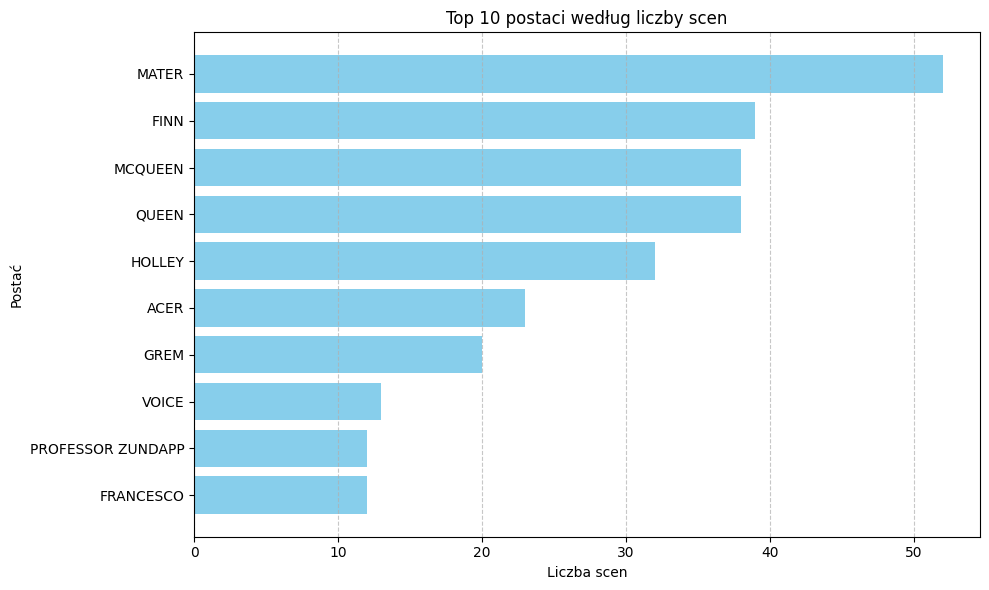

In [25]:
import matplotlib.pyplot as plt

if not character_ranking:
    print("Błąd: Brak danych do wygenerowania wykresu. Ranking jest pusty.")
else:
    # Pobranie top 10 postaci
    top_10 = character_ranking[:10]
    names = [item[0] for item in top_10][::-1]  # Odwr3cenie dla wykresu poziomego
    counts = [item[1] for item in top_10][::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(names, counts, color='skyblue')
    plt.xlabel('Liczba scen')
    plt.ylabel('Postać')

    title = 'Top 10 postaci według liczby scen'
    if len(character_ranking) < 10:
        title = f'Top {len(character_ranking)} postaci według liczby scen (wszystkie wykryte)'

    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#### Po uruchomieniu powinieneś zobaczyć


- Jeden poziomy wykres z nazwami postaci i długościami słupków odpowiadającymi liczbie scen.
- Wyraźny tytuł i podpisane osie.
- Brak dodatkowych elementów, które utrudniałyby szybkie odczytanie rankingu.


#### Pytanie interpretacyjne

Czy rozkład obecności postaci wygląda na skoncentrowany wokół jednej osi fabularnej, czy bardziej rozproszony między kilka ważnych postaci?


---
## Etap 4: Od scen do relacji między postaciami

Tutaj przechodzimy od obecności postaci do ich współwystępowania. To właśnie z tych danych powstanie sieć relacji.


### Krok 4A. Pary współwystąpień wewnątrz pojedynczych scen

#### Cel i sens analityczny

Każda scena z co najmniej dwiema postaciami dostarcza zestawu potencjalnych relacji, które można później zagregować w całym scenariuszu.


#### Prompt dla modelu

```text
Kontekst:
Relacja między dwiema postaciami pojawia się wtedy, gdy obie występują w tej samej scenie.

Wejście:
Lista scen z unikalnymi postaciami.

Zadanie:
Dla każdej sceny wygeneruj wszystkie unikalne pary postaci występujących razem. Zachowaj wynik tak, aby można było później zsumować go dla całego scenariusza.

Pokaż wynik:
- liczbę scen, z których udało się utworzyć przynajmniej jedną parę,
- próbkę 15 wierszy w formie `numer sceny | postać A | postać B`.

Warunek poprawności:
Para nie może łączyć postaci z samą sobą, a ta sama para nie powinna pojawiać się podwójnie w obrębie jednej sceny. Zachowaj stały porządek zapisu par, aby później łatwo je sumować.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem wynika z tego, że sceny mają zbyt mało postaci, czy z niespójności wcześniejszych danych.

Nie rób jeszcze:
Nie sumuj jeszcze wyników dla całego scenariusza.
```


In [26]:
import itertools

scene_pairs = []

for scene in final_scenes:
    chars = scene['postacie']
    if len(chars) >= 2:
        # Generate all unique combinations of 2 characters
        # Sorting ensures (A, B) and (B, A) are treated as the same pair
        pairs = list(itertools.combinations(sorted(chars), 2))
        for p in pairs:
            scene_pairs.append({
                'numer': scene['numer'],
                'p1': p[0],
                'p2': p[1]
            })

scenes_with_pairs = len(set(p['numer'] for p in scene_pairs))

if not scene_pairs:
    print("Błąd: Nie udało się utworzyć żadnej pary. Możliwe, żena każda scena zawiera maksymalnie jedną postać.")
else:
    print(f"Liczba scen z relacjami: {scenes_with_pairs}")
    print(f"Łączna liczba wystąpień par: {len(scene_pairs)}")
    print("\nPr3bka 15 wierszy (numer sceny | postać A | postać B):")
    print("-" * 60)
    for p in scene_pairs[:15]:
        print(f"{p['numer']:3} | {p['p1']:25} | {p['p2']}")

Liczba scen z relacjami: 89
Łączna liczba wystąpień par: 1526

Pr3bka 15 wierszy (numer sceny | postać A | postać B):
------------------------------------------------------------
  1 | COMBAT SHIP               | CRABBY
  1 | COMBAT SHIP               | FINN
  1 | COMBAT SHIP               | WHEN ---
  1 | CRABBY                    | FINN
  1 | CRABBY                    | WHEN ---
  1 | FINN                      | WHEN ---
  2 | ACER                      | COMBAT SHIP
  2 | ACER                      | CRANE ---
  2 | ACER                      | FINN
  2 | ACER                      | GREM
  2 | ACER                      | NOSY PACER
  2 | ACER                      | PROFESSOR ZUNDAPP
  2 | COMBAT SHIP               | CRANE ---
  2 | COMBAT SHIP               | FINN
  2 | COMBAT SHIP               | GREM


#### Po uruchomieniu powinieneś zobaczyć


- Informację, z ilu scen udało się utworzyć relacje.
- Próbkę pojedynczych par współwystąpień przypisanych do numerów scen.
- Brak duplikatów tej samej pary w obrębie jednej sceny.


### Krok 4B. Tabela relacji dla całego scenariusza

#### Cel i sens analityczny

Po zsumowaniu wszystkich par otrzymujemy podstawową tabelę krawędzi, z której można już budować sieć.


#### Prompt dla modelu

```text
Kontekst:
Masz listę par współwystąpień wygenerowanych dla poszczególnych scen.

Wejście:
Wynik kroku z parami współwystąpień.

Zadanie:
Zsumuj wszystkie powtarzające się pary w całym scenariuszu i utwórz tabelę relacji. Każda relacja ma opisywać, jak często dana para postaci występuje razem. Zachowaj tę tabelę do etapów sieciowych.

Pokaż wynik:
- liczbę unikalnych relacji,
- 15 najsilniejszych wierszy w formie `postać A | postać B | siła relacji`.

Warunek poprawności:
Ta sama relacja nie może pojawiać się kilka razy pod różnymi wariantami kolejności zapisu.

Jeśli wystąpi błąd:
Wyświetl krótką informację, że nie udało się utworzyć relacji albo że wynik jest pusty.

Nie rób jeszcze:
Nie buduj jeszcze sieci i nie zapisuj plików.
```


In [27]:
from collections import Counter

# Sumowanie wszystkich par w całym scenariuszu
# Para (p1, p2) już jest posortowana alfabetycznie w poprzednim kroku
edge_counts = Counter()

for p in scene_pairs:
    edge_counts[(p['p1'], p['p2'])] += 1

# Konwersja do listy słownik3w dla łatwiejszego przetwarzania
relationship_table = []
for (p1, p2), weight in edge_counts.items():
    relationship_table.append({
        'postać_A': p1,
        'postać_B': p2,
        'siła': weight
    })

# Sortowanie według siły relacji (malejąco)
relationship_table = sorted(relationship_table, key=lambda x: x['siła'], reverse=True)

if not relationship_table:
    print("Błąd: Nie udało się utworzyć tabeli relacji. Brak par wsp3łwystąpień.")
else:
    print(f"Liczba unikalnych relacji: {len(relationship_table)}")
    print("\n15 najsilniejszych relacji (postać A | postać B | siła):")
    print("-" * 65)
    for rel in relationship_table[:15]:
        print(f"{rel['postać_A']:25} | {rel['postać_B']:25} | {rel['siła']}")

Liczba unikalnych relacji: 694

15 najsilniejszych relacji (postać A | postać B | siła):
-----------------------------------------------------------------
MCQUEEN                   | QUEEN                     | 38
MATER                     | MCQUEEN                   | 28
MATER                     | QUEEN                     | 28
FINN                      | HOLLEY                    | 27
FINN                      | MATER                     | 23
HOLLEY                    | MATER                     | 21
ACER                      | GREM                      | 16
GREM                      | MATER                     | 14
ACER                      | MATER                     | 13
FRANCESCO                 | MCQUEEN                   | 11
FRANCESCO                 | QUEEN                     | 11
ACER                      | FINN                      | 10
FINN                      | GREM                      | 9
LUIGI                     | MCQUEEN                   | 9
LUIGI                

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę unikalnych relacji między postaciami.
- Tabelę pokazującą najsilniejsze duety wraz z siłą ich współwystępowania.
- Wyniki posortowane od najsilniejszej do najsłabszej relacji.


#### Pytanie interpretacyjne

Które duety wydają się centralne dla narracji i czy ich siła wynika raczej z długotrwałej osi fabuły, czy z wielu powracających spotkań?


---
## Etap 5: Sieć, podgląd i eksport danych

Na końcu zamieniamy tabelę relacji w sieć, oglądamy jej prosty podgląd i zapisujemy pliki do dalszej analizy poza Colabem.


### Krok 5A. Zbudowanie sieci relacji

#### Cel i sens analityczny

To moment przejścia od tabeli relacji do właściwej reprezentacji sieciowej, na której można liczyć miary i rysować strukturę powiązań.


#### Prompt dla modelu

```text
Kontekst:
Tabela relacji opisuje już, które postacie są połączone i jak silne jest to połączenie.

Wejście:
Tabela relacji z poprzedniego kroku.

Zadanie:
Zbuduj sieć, w której węzłami są postacie, a połączenia opisują ich współwystępowanie. Siła relacji ma zostać zachowana przy każdym połączeniu. Zachowaj gotową sieć do następnego kroku.

Pokaż wynik:
- liczbę węzłów,
- liczbę połączeń,
- krótką listę 10 postaci z największą liczbą połączeń.

Warunek poprawności:
Każda relacja z tabeli powinna pojawić się w sieci dokładnie raz.

Jeśli wystąpi błąd:
Wyjaśnij, że tabela relacji jest pusta albo niespójna i dlatego nie da się zbudować sieci.

Nie rób jeszcze:
Nie rysuj jeszcze grafu i nie zapisuj plików.
```


In [28]:
import networkx as nx

# Tworzenie pustego grafu nieskierowanego
G = nx.Graph()

if not relationship_table:
    print("Błąd: Tabela relacji jest pusta. Nie można zbudować sieci.")
else:
    # Dodawanie krawędzi z wagami do grafu
    for rel in relationship_table:
        G.add_edge(rel['postać_A'], rel['postać_B'], weight=rel['siła'])

    print(f"Liczba węzł3w (postaci): {G.number_of_nodes()}")
    print(f"Liczba połączeń (relacji): {G.number_of_edges()}")

    # Ranking postaci według stopnia (liczby połączeń)
    degree_dict = dict(G.degree())
    top_connected = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

    print("\n10 postaci z największą liczbą połączeę:")
    print("-" * 40)
    for char, degree in top_connected[:10]:
        print(f"{char:25} | {degree}")

Liczba węzł3w (postaci): 76
Liczba połączeń (relacji): 694

10 postaci z największą liczbą połączeę:
----------------------------------------
MATER                     | 66
FINN                      | 62
MCQUEEN                   | 56
QUEEN                     | 56
HOLLEY                    | 50
ACER                      | 43
PROFESSOR ZUNDAPP         | 42
GREM                      | 41
LUIGI                     | 39
SARGE                     | 37


#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość sieci: węzły i połączenia.
- Krótką listę najlepiej połączonych postaci.
- Brak wizualizacji na tym etapie: chodzi tylko o potwierdzenie, że sieć została zbudowana poprawnie.


### Krok 5B. Podgląd grafu w notatniku

#### Cel i sens analityczny

Wizualny podgląd pomaga zobaczyć, czy sieć ma jedno centrum, kilka grup albo bardziej rozproszoną strukturę.


#### Prompt dla modelu

```text
Kontekst:
Masz już zbudowaną sieć relacji między postaciami.

Wejście:
Gotowa sieć z poprzedniego kroku.

Zadanie:
Narysuj prosty podgląd sieci bezpośrednio w notatniku. Niech bardziej połączone postacie będą lepiej widoczne, a silniejsze relacje wyraźniejsze. Dodaj etykiety przynajmniej dla najważniejszych postaci.

Pokaż wynik:
- pojedynczy rysunek sieci z tytułem,
- czytelne etykiety najważniejszych postaci,
- różnicę widoczną między słabszymi i silniejszymi relacjami.

Warunek poprawności:
Jeśli sieć jest bardzo gęsta, ogranicz liczbę etykiet albo uprość podgląd i krótko wyjaśnij ten wybór, zamiast tworzyć nieczytelny obraz.

Jeśli wystąpi błąd:
Wyświetl informację, że sieć jest zbyt mała albo zbyt gęsta, aby dało się ją pokazać w czytelnej formie bez dodatkowego uproszczenia.

Nie rób jeszcze:
Nie zapisuj jeszcze plików wyjściowych.
```


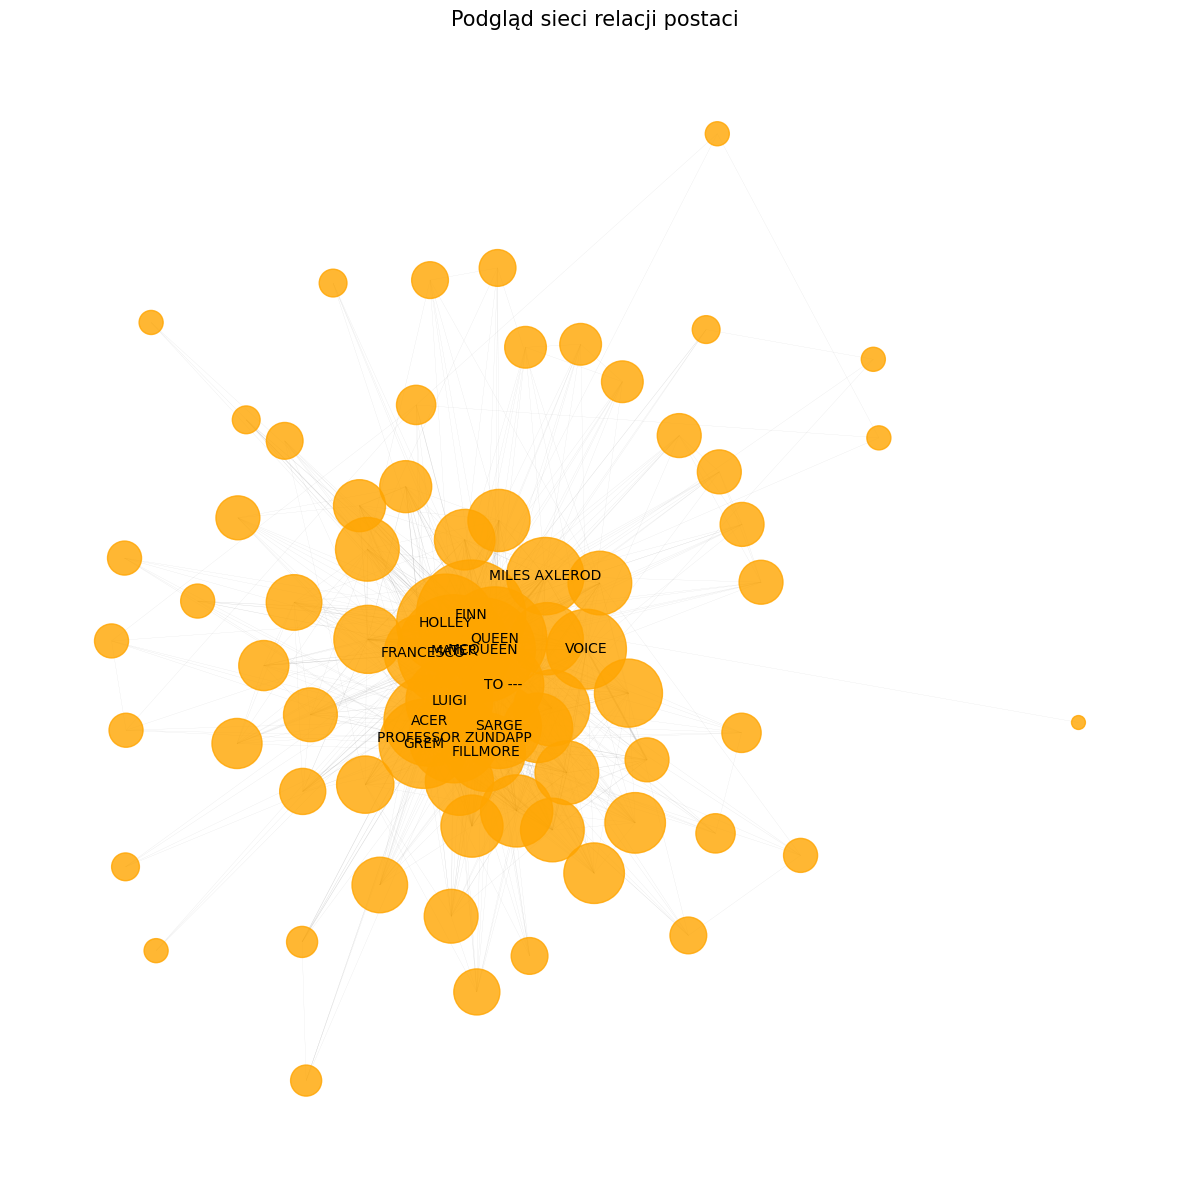


Uwaga: Ze względu na dużą liczbę węzł3w, etykiety są wyświetlane tylko dla kluczowych postaci.


In [29]:
import matplotlib.pyplot as plt
import networkx as nx

if not G or G.number_of_nodes() == 0:
    print("Błąd: Sieć jest pusta. Nie można wygenerować podglądu.")
else:
    plt.figure(figsize=(12, 12))

    # Layout for the nodes
    pos = nx.spring_layout(G, k=0.5, iterations=50)

    # Node sizes based on degree (number of connections)
    degrees = dict(G.degree())
    node_sizes = [v * 100 for v in degrees.values()]

    # Edge widths based on weights (strength of relationship)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_weight = max(weights) if weights else 1
    edge_widths = [(w / max_weight) * 5 for w in weights]

    # Drawing the network
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='orange', alpha=0.8)

    # Labels for the most important characters (top 15 by degree)
    top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:15]
    labels = {node: node for node, deg in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family='sans-serif')

    plt.title("Podgląd sieci relacji postaci", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    if G.number_of_nodes() > 30:
        print("\nUwaga: Ze względu na dużą liczbę węzł3w, etykiety są wyświetlane tylko dla kluczowych postaci.")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden rysunek sieci umieszczony bezpośrednio pod komórką.
- Większą widoczność postaci silniej osadzonych w sieci oraz wyraźniejsze relacje o większej sile.
- Krótką notę wyjaśniającą uproszczenie, jeśli sieć okaże się bardzo gęsta.


#### Pytanie interpretacyjne

Czy na podglądzie widać jednego głównego pośrednika, kilka grup postaci czy raczej gęstą strukturę bez wyraźnego centrum?


### Krok 5C. Eksport danych do dalszej analizy

#### Cel i sens analityczny

Ostatni krok przygotowuje dwa pliki, które można pobrać z Colab i analizować dalej w innych narzędziach.


#### Prompt dla modelu

```text
Kontekst:
Masz gotową tabelę relacji oraz zbudowaną sieć postaci.

Wejście:
Tabela relacji i gotowa sieć.

Zadanie:
Zapisz tabelę relacji do pliku `krawedzie.csv`, a całą sieć do pliku `graf_postaci.graphml`. Na końcu pokaż krótko, jakie pliki powstały i gdzie student może je znaleźć w środowisku notatnika.

Pokaż wynik:
- komunikat o zapisaniu obu plików,
- listę nazw zapisanych plików,
- krótką wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki powinny być niepuste i gotowe do otwarcia poza notatnikiem.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i z jakiego powodu.

Nie rób jeszcze:
Nie wykonuj już dalszej analizy.
```


In [30]:
import pandas as pd
import networkx as nx
import os

try:
    # 1. Zapisywanie tabeli krawędzi do CSV
    df_edges = pd.DataFrame(relationship_table)
    df_edges.to_csv('krawedzie.csv', index=False, encoding='utf-8')

    # 2. Zapisywanie sieci do GraphML
    nx.write_graphml(G, 'graf_postaci.graphml')

    print("Sukces: Pliki zostały zapisane poprawnie!")
    print("Utworzone pliki:")
    print("- krawedzie.csv (tabela relacji)")
    print("- graf_postaci.graphml (pełna sieć do Gephi/Cytoscape)")

    print("\nInstrukcja pobierania:")
    print("1. Kliknij ikonę folderu w lewym panelu bocznym Google Colab.")
    print("2. Znajdź pliki na liście.")
    print("3. Kliknij trzy kropki obok nazwy pliku i wybierz 'Download' (Pobierz).")

except Exception as e:
    print(f"Wystąpił błąd podczas zapisywania plików: {e}")

Sukces: Pliki zostały zapisane poprawnie!
Utworzone pliki:
- krawedzie.csv (tabela relacji)
- graf_postaci.graphml (pełna sieć do Gephi/Cytoscape)

Instrukcja pobierania:
1. Kliknij ikonę folderu w lewym panelu bocznym Google Colab.
2. Znajdź pliki na liście.
3. Kliknij trzy kropki obok nazwy pliku i wybierz 'Download' (Pobierz).


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie zapisania plików `krawedzie.csv` i `graf_postaci.graphml`.
- Krótką listę lub komunikat pokazujący, że pliki są widoczne w środowisku notatnika.
- Jednozdaniową wskazówkę, jak pobrać pliki z Google Colab.


---
## Co dalej?

- Otwórz `graf_postaci.graphml` w Gephi albo innym narzędziu do analizy sieci, aby policzyć miary centralności i sprawdzić społeczności postaci.
- Otwórz `krawedzie.csv` w arkuszu kalkulacyjnym, jeśli chcesz filtrować, sortować i porównywać relacje bez pracy na grafie.
- Zmień adres scenariusza w komórce parametru i porównaj strukturę narracyjną różnych filmów.
- Jeśli któryś krok działa źle, poproś model o poprawienie tylko tego jednego fragmentu zamiast generowania całego rozwiązania od nowa.
